# **Logistic Regression: Scorecard**  

> **Author**: David Thébault.  
> **Date**: October 18, 2025.
> 
> **Objective**:  
This notebook aims to provide a **comprehensive use cas of the logistic regression** to build a performing scorecard for diabete predictions.

## Packages & functions

In [1]:
# The libraries imports
import os
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

import calculate_point_biserial
import calculate_eigenvalues
import calculate_gvif
import cramers_v, cramers_v_matrix

## Load the Dataset

We will use the diabetes dataset to show how to perform logistic regression in Python.

In [2]:
# Load the dataset
data_path = '/Users/davidtbo/Library/Mobile Documents/com~apple~CloudDocs/data/external'
file_path = os.path.join(data_path, 'diabetes.csv')

if not os.path.exists(file_path):
    raise FileNotFoundError(f"Fichier introuvable : {file_path}")

df = pd.read_csv(file_path)

# Standardize column names
df.columns = df.columns.str.lower()

# Replace invalid zeros with NaN (common issue in diabetes dataset)
cols_with_invalid_zero = ["glucose", "bloodpressure", "skinthickness", "insulin", "bmi"]
df[cols_with_invalid_zero] = df[cols_with_invalid_zero].replace(0, np.nan)

# Drop duplicates
df = df.drop_duplicates()

# Quick diagnostic
print(df.info())
print(df.isna().mean())

df.head()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   pregnancies               768 non-null    int64  
 1   glucose                   763 non-null    float64
 2   bloodpressure             733 non-null    float64
 3   skinthickness             541 non-null    float64
 4   insulin                   394 non-null    float64
 5   bmi                       757 non-null    float64
 6   diabetespedigreefunction  768 non-null    float64
 7   age                       768 non-null    int64  
 8   outcome                   768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB
None
pregnancies                 0.000000
glucose                     0.006510
bloodpressure               0.045573
skinthickness               0.295573
insulin                     0.486979
bmi                         0.014323
diabetespedigreefunction

,pregnancies,glucose,bloodpressure,skinthickness,insulin,bmi,diabetespedigreefunction,age,outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


## Introduce categorical

The initial dataset only contains numerical variables.  
For pedagogical purposes, we will incorporate categorical variables 
in a logistic regression model to predict diabetes.  
Note tha categorize continuous variables can help to better capture 
non-linear relationships and improve interpretability.  

**Age:** the age variable will be categorized into three distinct groups: 

* Young
* Middle-aged
* Senior

**Number of pregnancies:** this variable will be categorized based on medical thresholds into the following groups:

* None (0 pregnancies)
* Low (1-2 pregnancies)
* Moderate (3-5 pregnancies)
* High (6 or more pregnancies)

In [3]:
# Categorize 'age' into 3 categories

bins_age = [0, 30, 50, 100]
labels_age = ['Young', 'Middle-aged', 'Senior']
df['age_category'] = pd.cut(df['age'], bins=bins_age, labels=labels_age, include_lowest=True)

df['age_category'].value_counts()

age_category
Young          417
Middle-aged    270
Senior          81
Name: count, dtype: int64

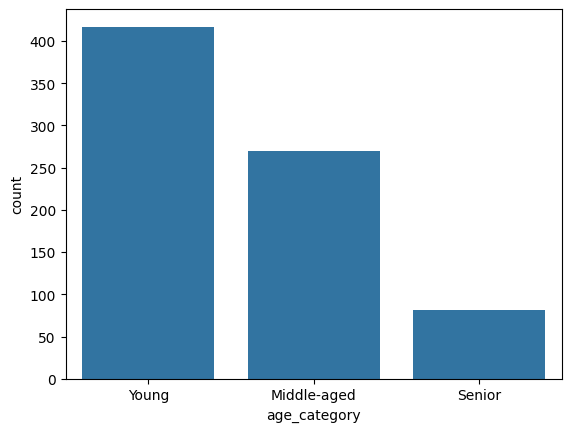

In [4]:
# Barplots for categorical variables

sns.countplot(data=df, x='age_category')
plt.show()

In [5]:
# Categorize 'number of pregnancies' into 4 categories

bins = [-1, 0, 2, 5, float('inf')]
labels = ['None', 'Low', 'Moderate', 'High']
df['pregnancies_category'] = pd.cut(df['pregnancies'], bins=bins, labels=labels)

# Check the distribution of pregnancy categories
df['pregnancies_category'].value_counts()

pregnancies_category
Low         238
High        219
Moderate    200
None        111
Name: count, dtype: int64

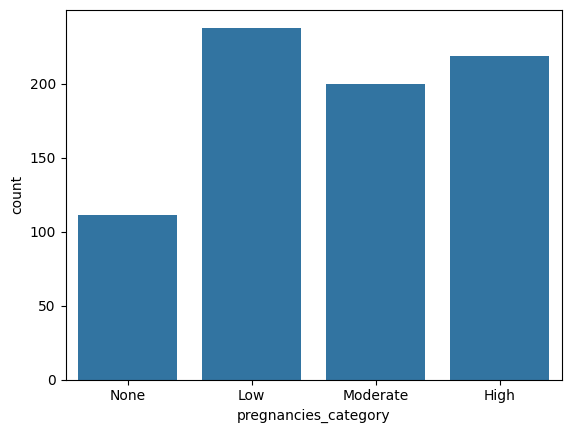

In [6]:
# Barplots for categorical variables

sns.countplot(data=df, x='pregnancies_category')
plt.show()

In [7]:
# for the modeling, we only keep the categorical versions)

df.drop(columns=['age', 'pregnancies'], inplace=True)
df.head()

,glucose,bloodpressure,skinthickness,insulin,bmi,diabetespedigreefunction,outcome,age_category,pregnancies_category
0,148.0,72.0,35.0,NaN,33.6,0.627,1,Middle-aged,High
1,85.0,66.0,29.0,NaN,26.6,0.351,0,Middle-aged,Low
2,183.0,64.0,NaN,NaN,23.3,0.672,1,Middle-aged,High
3,89.0,66.0,23.0,94.0,28.1,0.167,0,Young,Low
4,137.0,40.0,35.0,168.0,43.1,2.288,1,Middle-aged,None


## Exploratory Data Analysis

In [8]:
# Quick missing values diagnostic
print(df.isna().mean())

glucose                     0.006510
bloodpressure               0.045573
skinthickness               0.295573
insulin                     0.486979
bmi                         0.014323
diabetespedigreefunction    0.000000
outcome                     0.000000
age_category                0.000000
pregnancies_category        0.000000
dtype: float64


**insulin** and **skinthickness** have a lot of missing values. This is an issue for the Logistic Regression.

Analyse the distribution of each variable

In [9]:
print(df.describe(include='all').to_string())

           glucose  bloodpressure  skinthickness     insulin         bmi  diabetespedigreefunction     outcome age_category pregnancies_category
count   763.000000     733.000000     541.000000  394.000000  757.000000                768.000000  768.000000          768                  768
unique         NaN            NaN            NaN         NaN         NaN                       NaN         NaN            3                    4
top            NaN            NaN            NaN         NaN         NaN                       NaN         NaN        Young                  Low
freq           NaN            NaN            NaN         NaN         NaN                       NaN         NaN          417                  238
mean    121.686763      72.405184      29.153420  155.548223   32.457464                  0.471876    0.348958          NaN                  NaN
std      30.535641      12.382158      10.476982  118.775855    6.924988                  0.331329    0.476951          NaN       

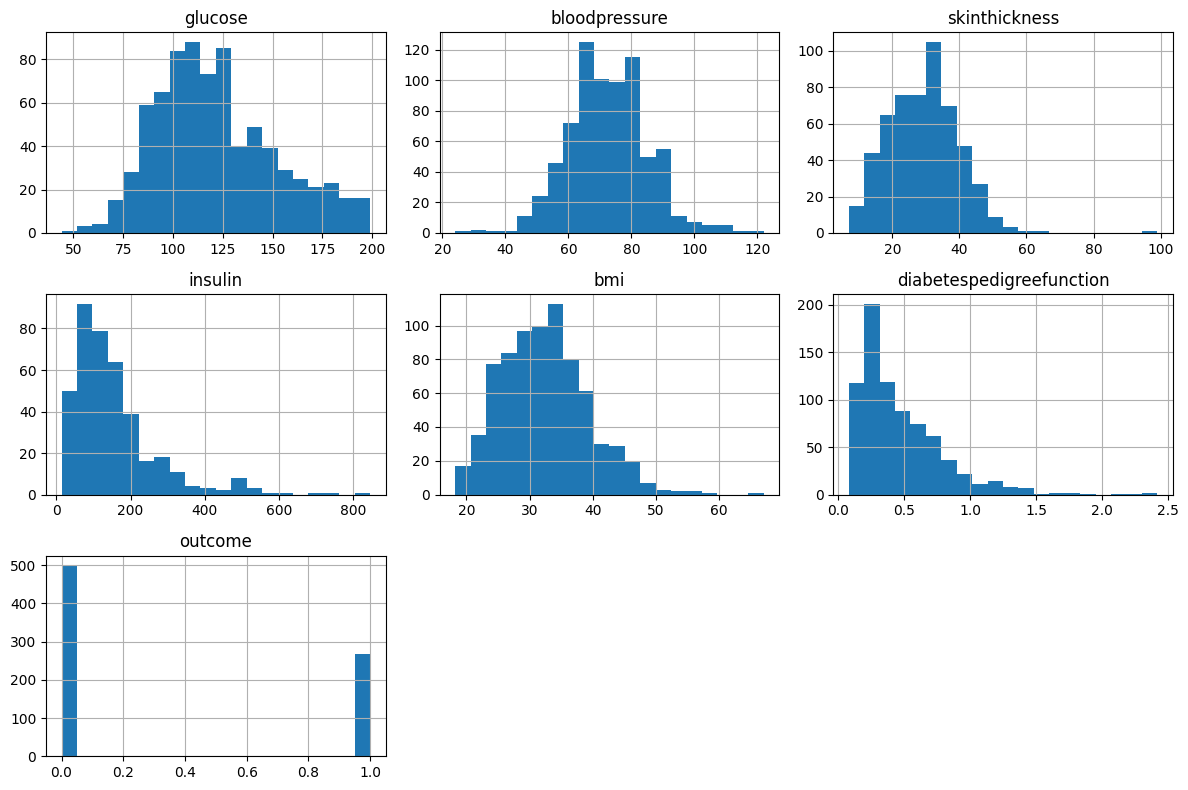

In [10]:
# Histograms for numerical variables

df.hist(figsize=(12, 8), bins=20)
plt.tight_layout()
plt.show()

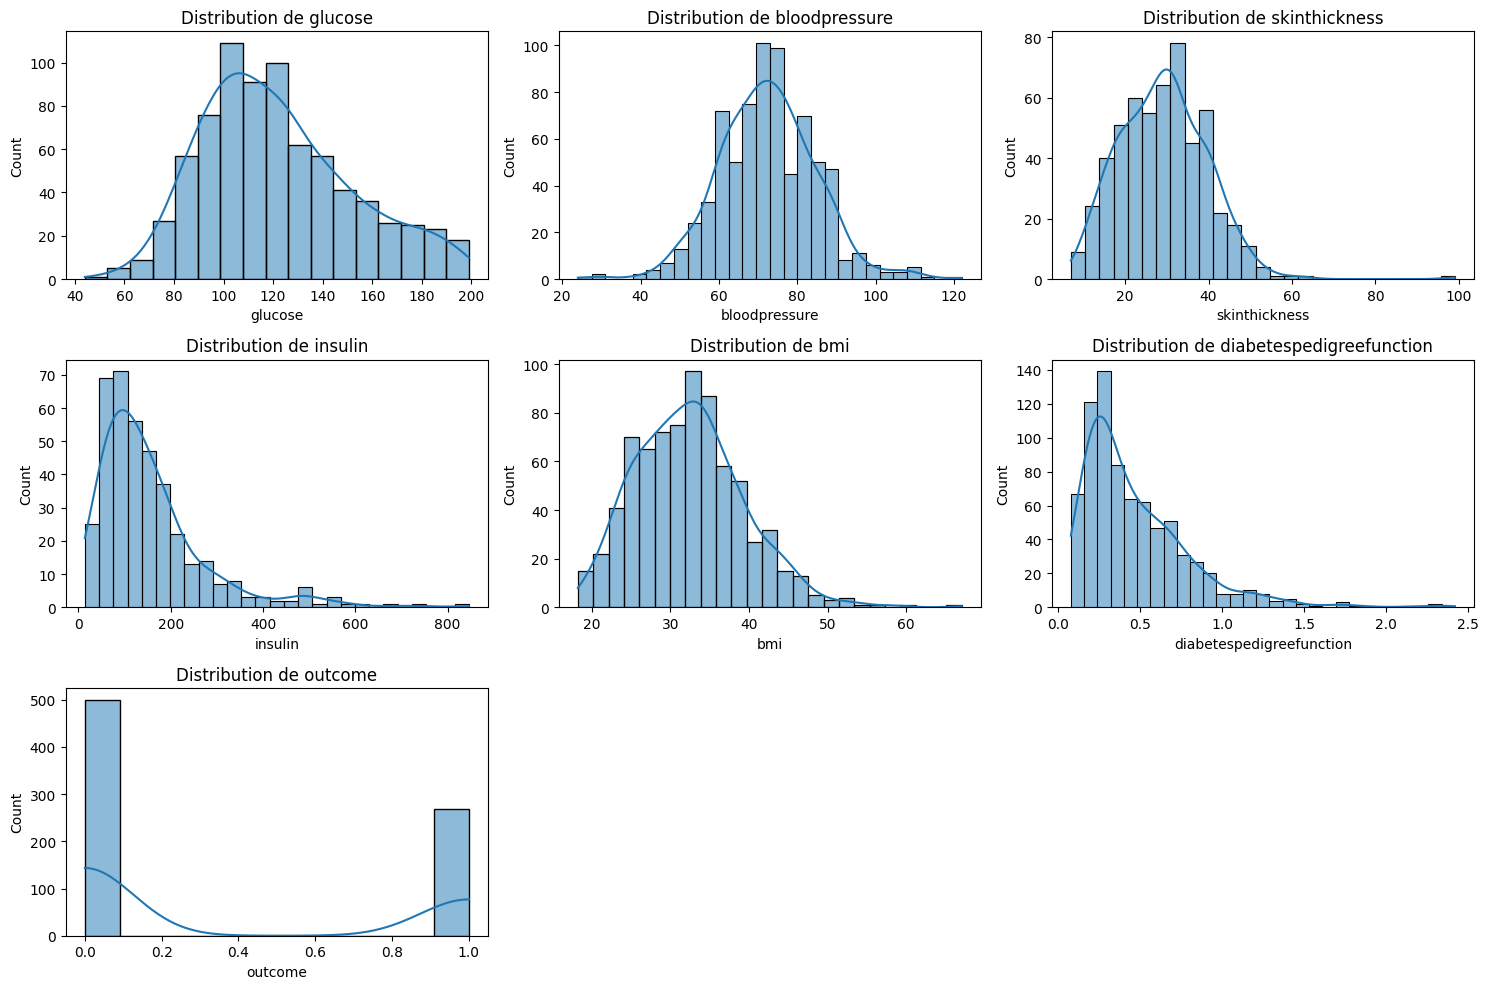

In [11]:
# Distribution plots (Seaborn) - better visualization of distributions

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

numeric_cols = df.select_dtypes(include='number').columns
n_cols = len(numeric_cols)

# Définir la grille (3 x 3)
rows = int(np.ceil(n_cols / 3))
cols = 3

fig, axes = plt.subplots(rows, cols, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution de {col}")

# Masquer les cases vides si le nombre de variables < 9
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

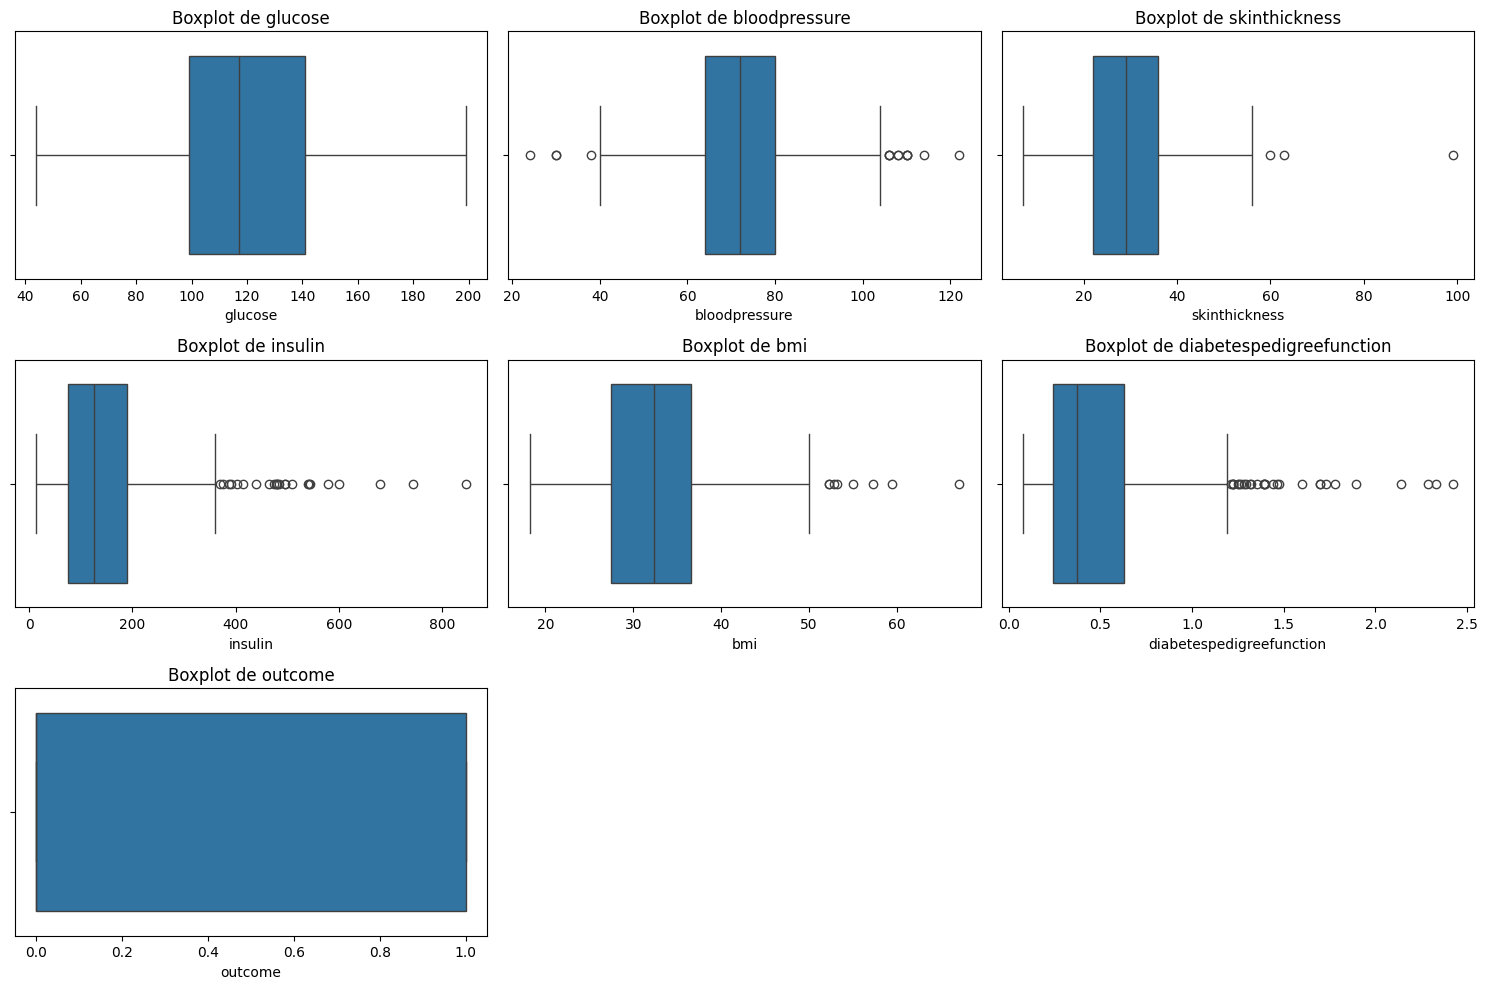

In [12]:
# Boxplots to detect outliers

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

numeric_cols = df.select_dtypes(include='number').columns
n_cols = len(numeric_cols)

# Définir la grille (3 x 3)
rows = int(np.ceil(n_cols / 3))
cols = 3

fig, axes = plt.subplots(rows, cols, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f"Boxplot de {col}")

# Masquer les cases vides si le nombre de variables < 9
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

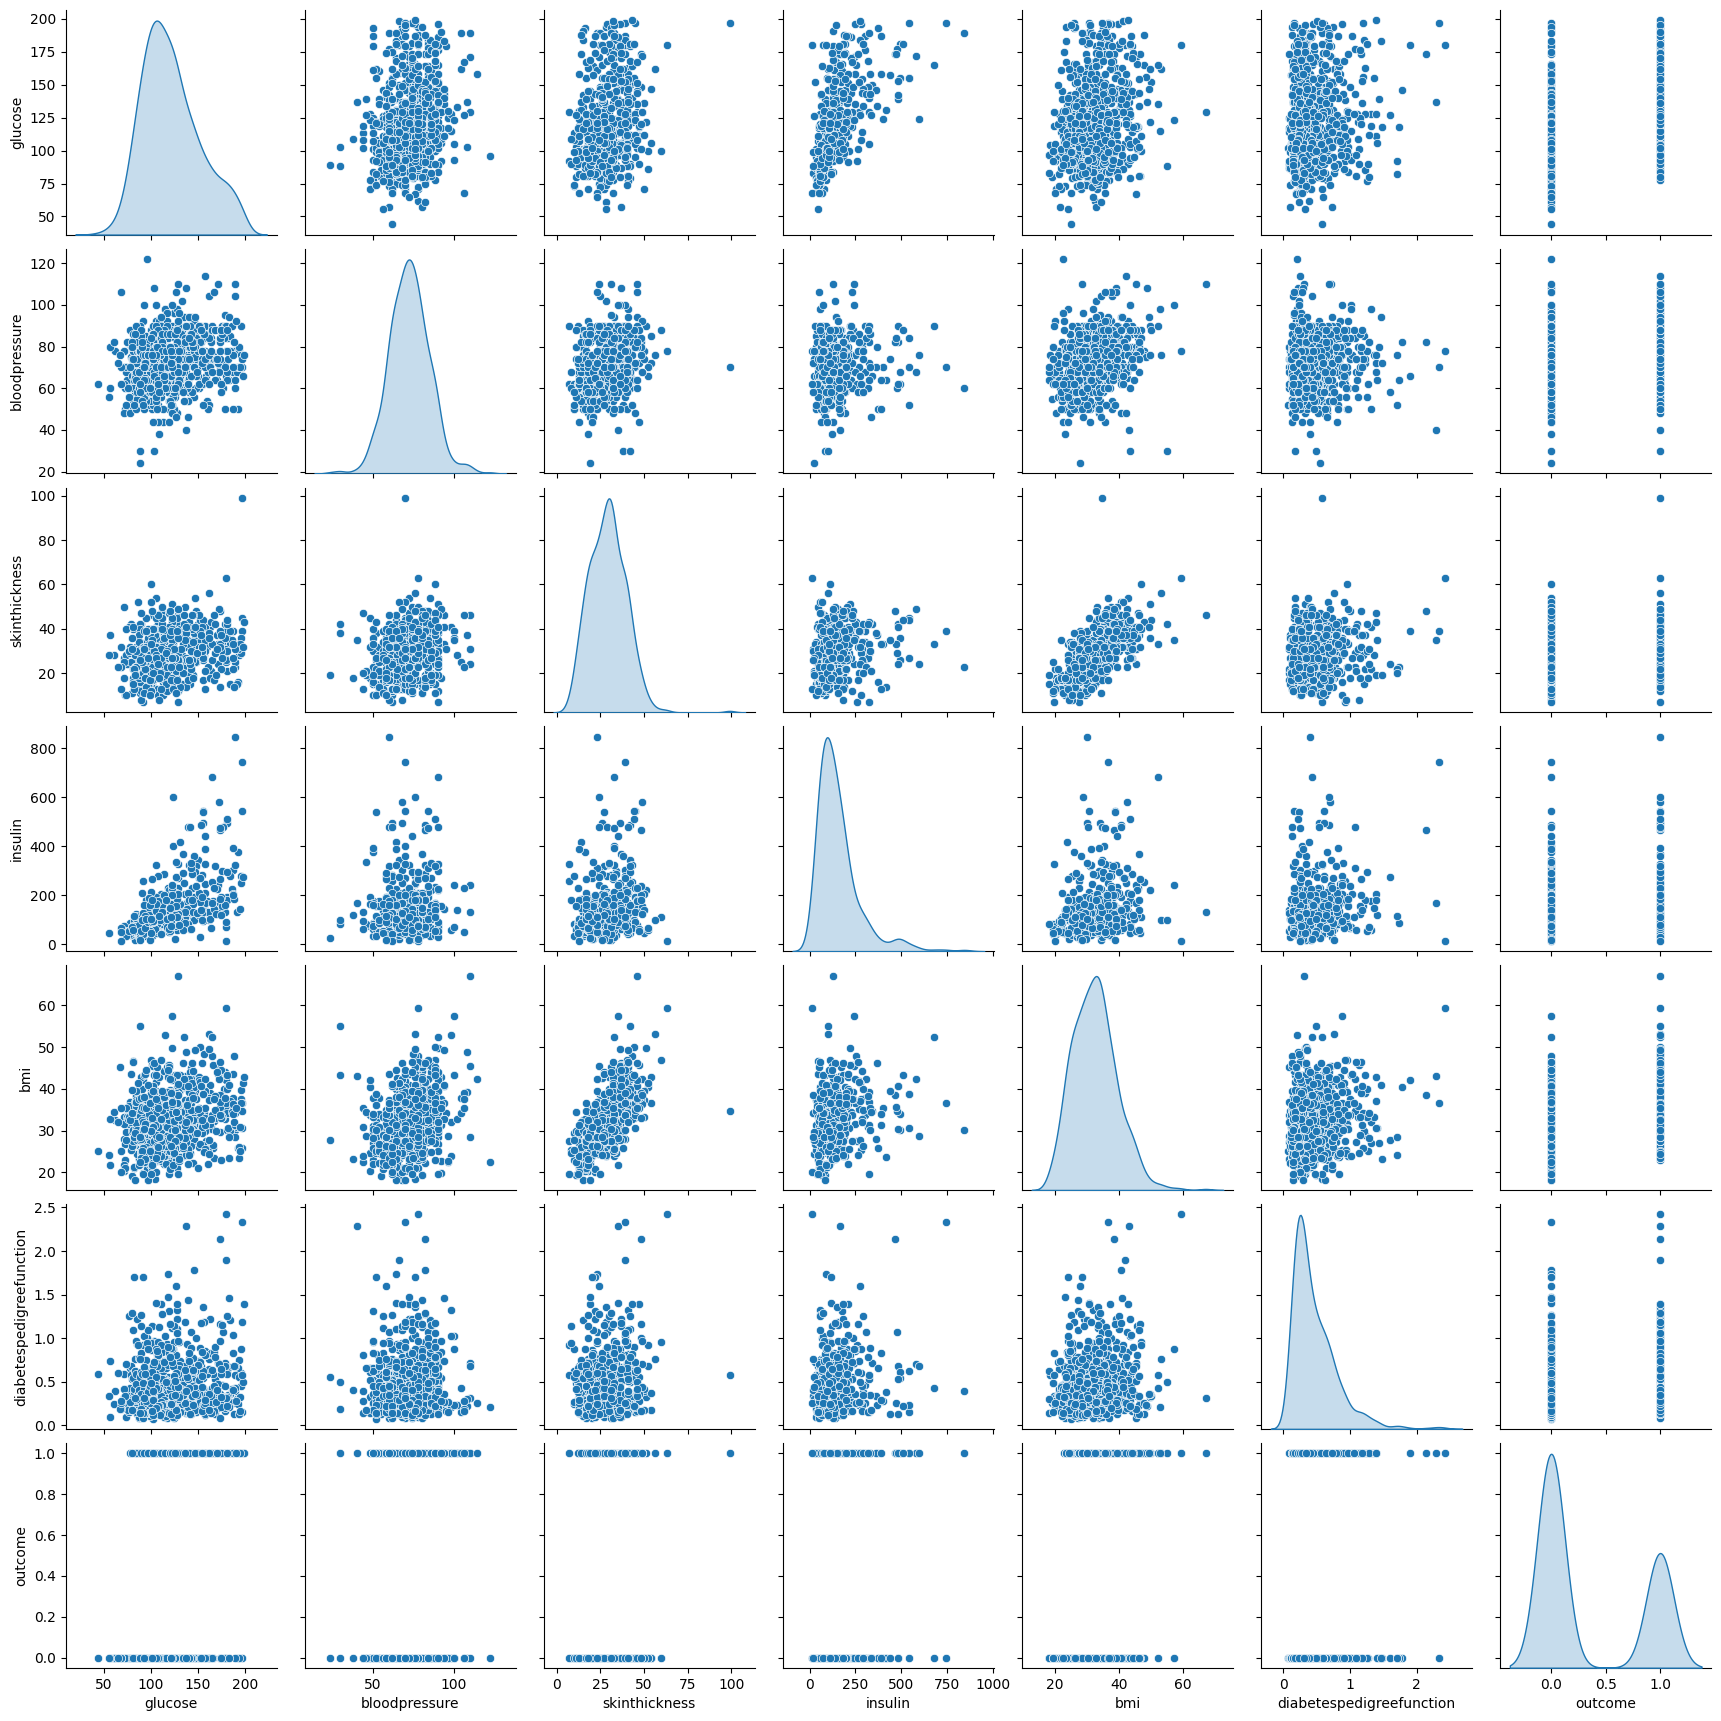

In [13]:
# Pairplot to see relationships between numerical variables

sns.pairplot(df, diag_kind='kde')
plt.show()

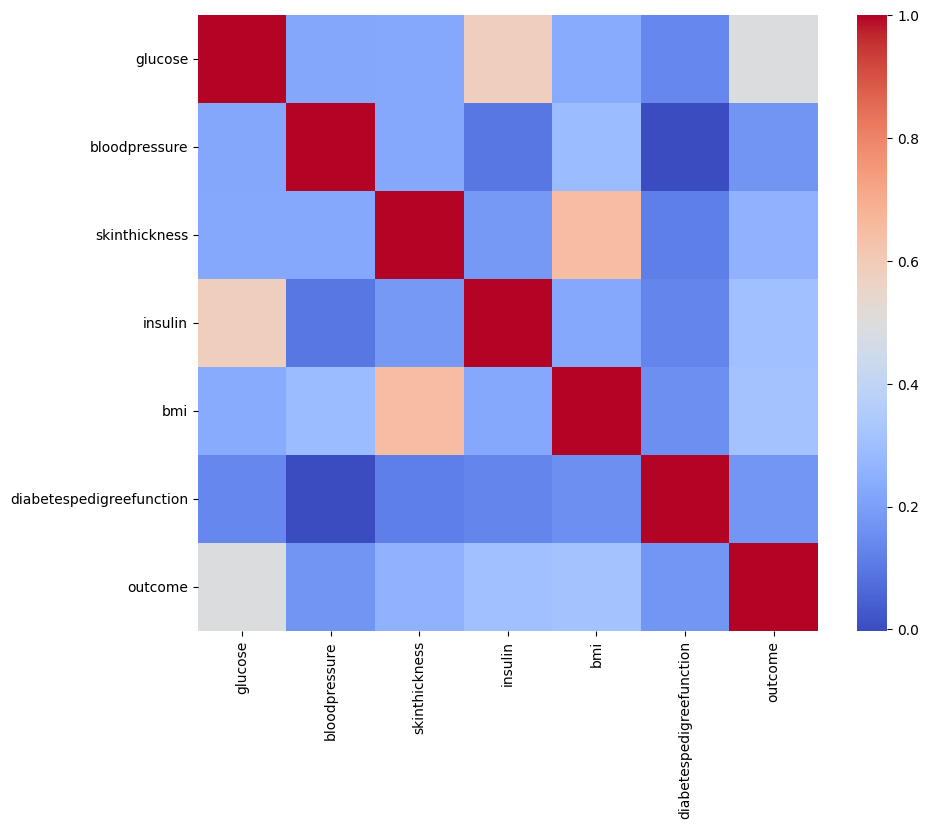

In [14]:
# Heatmap for correlation & detection of multicollinearity

plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=False, cmap='coolwarm')
plt.show()

## X, y split

In [15]:
X = df.drop(columns=['outcome'])
y = df['outcome']

## Train, test split

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

The model will be fit on the train dataset (X_train) and validate on the test dataset (X_test).

## numeric, categoric split

In [17]:
X_train_num = X_train.select_dtypes(include=[np.number])

X_train_num.head()

,glucose,bloodpressure,skinthickness,insulin,bmi,diabetespedigreefunction
602,124.0,74.0,36.0,NaN,27.8,0.100
429,95.0,82.0,25.0,180.0,35.0,0.233
623,94.0,70.0,27.0,115.0,43.5,0.347
209,184.0,84.0,33.0,NaN,35.5,0.355
589,73.0,NaN,NaN,NaN,21.1,0.342


In [18]:
X_train_cat = X_train.select_dtypes(exclude=[np.number])

X_train_cat.head()

,age_category,pregnancies_category
602,Young,Low
429,Middle-aged,Low
623,Young,None
209,Middle-aged,High
589,Young,None


## Pipeline categorical

Encoding categorical features $\rightarrow$ **dummy encoding** (one-hot encoding)

Risk best practices:
* les scorecards bancaires utilisent uniquement des variables numériques binées + WoE
* les variables catégorielles sont souvent instables
* elles compliquent la validation réglementaire
* elles augmentent le risque de sur‑ajustement
* elles sont rarement utilisées dans les modèles réglementés

Dans le pipeline pour ignorer les variables catégorielles:
> continuous_vars = list(selector.cut_points_.keys())  
> other_vars = [] # on ignore les variables catégorielles

In [ ]:
# Convert categorical variables to dummy variables:
X_train_dum = pd.get_dummies(
    X_train_cat, 
    columns=['age_category','pregnancies_category'], 
    drop_first=True, 
    dtype=int)

# Check
X_train_dum.info() # check everything is numeric
X_train_dum.head()

<class 'pandas.DataFrame'>
Index: 614 entries, 602 to 168
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   age_category_Middle-aged       614 non-null    int64
 1   age_category_Senior            614 non-null    int64
 2   pregnancies_category_Low       614 non-null    int64
 3   pregnancies_category_Moderate  614 non-null    int64
 4   pregnancies_category_High      614 non-null    int64
dtypes: int64(5)
memory usage: 28.8 KB


,age_category_Middle-aged,age_category_Senior,pregnancies_category_Low,pregnancies_category_Moderate,pregnancies_category_High
602,0,0,1,0,0
429,1,0,1,0,0
623,0,0,0,0,0
209,1,0,0,0,1
589,0,0,0,0,0


**Pearson correlation for dummy variables**

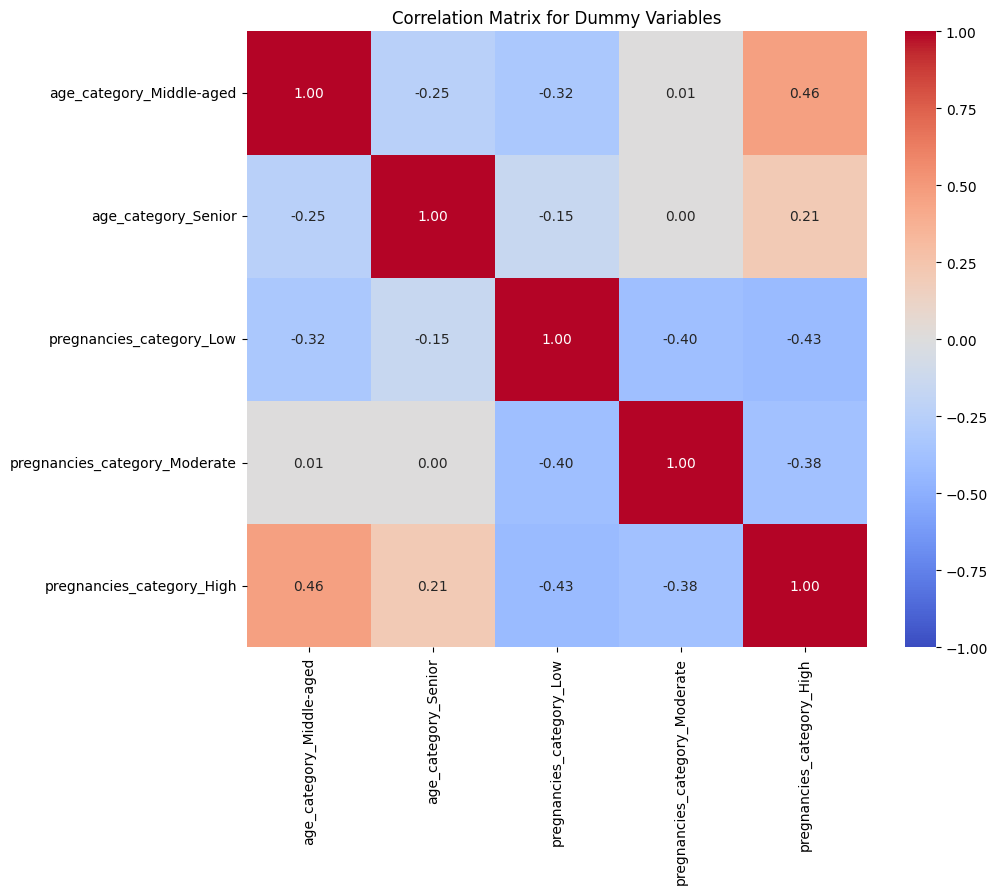

In [ ]:
# Calculate the correlation matrix for dummy variables
dummy_corr_matrix = X_train_dum.corr()

# Visualize the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(dummy_corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix for Dummy Variables")
plt.show()

**V-Cramer for categorical variables**

**Cramer's V** is a measure of association between two nominal variables, useful for assessing multicollinearity among dummy variables.  
It ranges from 0 (no association) to 1 (perfect association).  

Interpretation:

In [ ]:
# Need to import cramers_v_matrix function !!
# # Cramer's V correlation matrix for categorical variables
# cramersv_matrix = cramers_v_matrix(X_train_dum, X_train_dum.columns.tolist())

# plt.figure(figsize=(10, 8))
# sns.heatmap(cramersv_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=0, vmax=1)
# plt.title('Cramer\'s V Correlation Matrix')
# plt.show()

## Pipeline numeric

### Imputation

In [19]:
X_train_num.isna().sum()

glucose                       3
bloodpressure                29
skinthickness               189
insulin                     303
bmi                           9
diabetespedigreefunction      0
dtype: int64

In scorecard, we never make sophisticated imputation of missing values.  
We rather bin the numerical variables, and treat missing values as a separate bin (eg: assign to the worst category as unknown)  
or impute with median value because it is simple, stable, explicable and audit-friendly.

Rules for imputation of missing values

|Variable|Type|Reason|
|---|---|---|
|glucose|median|sensitive to outliers|
|bloodpressure|median|idem|
|skinthickness|median|idem|
|insulin|median|distribution very skewed|
|bmi|median|OMS standard|
|diabetespedigreefunction|-|no need of imputation|

In [20]:
X_train_num.fillna(X_train_num.median(), inplace=True)

X_train_num.head()

,glucose,bloodpressure,skinthickness,insulin,bmi,diabetespedigreefunction
602,124.0,74.0,36.0,130.0,27.8,0.100
429,95.0,82.0,25.0,180.0,35.0,0.233
623,94.0,70.0,27.0,115.0,43.5,0.347
209,184.0,84.0,33.0,130.0,35.5,0.355
589,73.0,72.0,29.0,130.0,21.1,0.342


### Features engineering

For explainability, we will discretize continuous variables into categories.

**Advantages of discretizing continuous variables and applying one‑hot encoding**
* Improved interpretability (XAI‑friendly):  
Category‑based coefficients are far easier to explain than coefficients on standardized continuous variables.  
For example, a term like bmi_25_30 = +0.42 is immediately interpretable,  
whereas a coefficient on a z‑scored BMI requires additional explanation.

* Robustness to extreme values:  
Outliers no longer distort the model because they are absorbed into the appropriate bin.  
This prevents extreme observations from disproportionately influencing the coefficients.

* Implicit modeling of non‑linear relationships:  
Logistic regression is inherently linear, but discretization introduces piecewise effects.  
This allows the model to capture non‑linear risk patterns  
(e.g., risk increasing sharply between certain ranges) without explicitly engineering polynomial terms.

* Greater temporal and distributional stability:  
Binned variables tend to be more stable over time,  
especially in regulated or production environments where shifts  
in the underlying distribution can degrade model performance.

* Easier validation and governance:  
In industries like banking or insurance, categorical bins are easier to audit,  
justify, and monitor. Each bin can be reviewed individually,  
making the model more transparent and compliant with regulatory expectations.

**Disadvantages**  
* Loss of information:  
Discretization collapses a continuous variable into a small number of categories,  
reducing granularity and potentially discarding predictive signal.  

* Increased dimensionality:  
Each discretized variable becomes multiple dummy variables,  
which can inflate the feature space and increase the risk of overfitting if not controlled.

* Sensitivity to binning choices:  
Poorly chosen cut points can distort relationships, create artificial boundaries,  
or hide meaningful variation. The model becomes dependent on the quality of the discretization strategy.

* Reduced performance for modern ML algorithms:  
Tree‑based models (Random Forest, XGBoost, LightGBM) typically perform better with continuous variables,  
as they naturally learn optimal splits. Discretization can therefore degrade performance in these contexts.

Different methods to handle categorical variables can be applied.

* Chi-square discretization

In [4]:
from chi_merge import chi_merge
print(chi_merge.__doc__)

Chi-square discretization (ChiMerge)
- Supervised method.  
- Merge the intervals while teh Chi-squre statistic is not significative.  
- Très utilisée en Scoring bancaire.


* Tukey’s fences (IQR‑based binning)

In [6]:
from tukey_binning import tukey_binning
print(tukey_binning.__doc__)

Tukey’s fences (IQR-based binning)
- Unsupervised method.
- Based on th quartiles to define natural borns.
- Very robust to outliers.
- Produce 4-5 typical intervals.


* Rank / quantile binning (equal‑frequency)

In [7]:
from quantile_binning import quantile_binning
print(quantile_binning.__doc__)

Quantile (rank / equal-frequency) binning
- Splits the variable into quantiles (quartiles, quintiles, deciles, etc.).
- Each bin contains approximately the same number of observations.
- Widely used in marketing and credit scoring.



* Equal‑width binning

In [9]:
from equal_width_binning import equal_width_binning
print(equal_width_binning.__doc__)

Equal width binning
- Constant width intervals.
- Simple but sensitive to outliers.
Parameters
----------
x : array-like, shape (n_samples,)
    Input data to be binned.
bins : int, optional (default=5)
    Number of bins to create.
Returns
-------
bin_edges : list
    List of bin edges.



* Equal‑frequency binning (version pandas)

In [10]:
from equal_freq_binning import equal_freq_binning
print(equal_freq_binning.__doc__)

Equal frequency binning (pandas version)
- Same number of observations per bin.
- Very stable and robust.
Parameters
----------
x : array-like, shape (n_samples,)
    Input data to be binned.
bins : int, optional (default=5)
    Number of bins to create.
Returns
-------
bin_edges : list
    List of bin edges.



* Discrétisation via arbre de régression

In [11]:
from tree_binning import tree_binning
print(tree_binning.__doc__)

Discretization through regression tree
- Supervised method.
- The tree automatically chooses the best cut points.
- The min_leaf_pct parameter ensures bins are sufficiently large.
- Very effective at capturing non-linearities.
Parameters
----------
x : array-like, shape (n_samples,)
    Input data to be binned.
y : array-like, shape (n_samples,)
    Target variable.
min_leaf_pct : float, optional (default=0.05)
    Minimum percentage of samples required in each leaf.
max_depth : int, optional (default=3)
    Maximum depth of the tree.
Returns
-------
cut_points : list
    List of cut points determined by the regression tree.



#### Best discretization

**Automatically selects the best binning method for each continuous variable**

In [28]:
from DiscretizerSelector import DiscretizerSelector
print(DiscretizerSelector.__doc__)


Automatically selects the best discretization method for each continuous
variable based on Information Value (IV).

This transformer evaluates several binning strategies, computes the IV
associated with each discretization, and retains the method and cut points
that maximize predictive power. It is typically used in scorecard modeling
to identify the most informative binning before applying monotonic
constraints and Weight of Evidence (WoE) encoding.

The selector:
- tests multiple discretization functions,
- computes IV for each candidate binning,
- selects the method with the highest IV,
- stores the chosen cut points for each variable.

Note
----
This transformer does not modify the data during `transform`. It only
identifies and stores the optimal discretization strategy. The actual
binning is applied later in the pipeline.

Parameters
----------
methods_dict : dict
    Mapping of method names to functions of the form
    `func(x, y) -> list_of_cut_points`.
    Each function must 

In [29]:
# Select the best discretization method and cut points for each numerical variable
MIN_LEAF_PCT = 0.2
NB_INTERVALS = 3

methods = {
    # "chi2": chi_merge, # trop lent
    "quantile": quantile_binning,
    "tukey": tukey_binning,
    "tree": lambda x, y: tree_binning(x, y, min_leaf_pct=MIN_LEAF_PCT),
    "equal_width": equal_width_binning,
    "equal_freq": lambda x, y: list(np.unique(np.quantile(x, np.linspace(0,1,NB_INTERVALS)))),
}

selector = DiscretizerSelector(methods_dict=methods)
selector.fit(X_train_num.select_dtypes(include=[np.number]), y_train)

,methods_dict,"{'equal_freq': <function <la...t 0x11cfec400>, 'equal_width': <module 'equa...h_binning.py'>, 'quantile': <module 'quan...e_binning.py'>, 'tree': <function <la...t 0x11cfec360>, ...}"
,max_bins,5


In [30]:
selector.best_methods_ , selector.cut_points_

({'glucose': 'equal_freq',
  'bloodpressure': 'equal_freq',
  'skinthickness': 'equal_freq',
  'insulin': 'equal_freq',
  'bmi': 'equal_freq',
  'diabetespedigreefunction': 'equal_freq'},
 {'glucose': [np.float64(56.0), np.float64(118.0), np.float64(199.0)],
  'bloodpressure': [np.float64(24.0), np.float64(72.0), np.float64(122.0)],
  'skinthickness': [np.float64(7.0), np.float64(29.0), np.float64(99.0)],
  'insulin': [np.float64(15.0), np.float64(130.0), np.float64(846.0)],
  'bmi': [np.float64(18.2), np.float64(32.0), np.float64(67.1)],
  'diabetespedigreefunction': [np.float64(0.078),
   np.float64(0.3755),
   np.float64(2.329)]})

#### Clean the cut points

* round cut points for better interpretability
* adjust manually if needed
* business validaion
* documentation for auditability.

We round manually the cut-points for better readability $\rightarrow$ not necessary here.

In [31]:
from round_cut_points import round_cut_points
print(round_cut_points.__doc__)


Rounds each cut-point in a list.
- ignores None
- ignores empty lists
- converts numpy types to Python floats



In [32]:
selector.cut_points_['bmi'] = round_cut_points(selector.cut_points_['bmi'], digits=0)
selector.cut_points_['diabetespedigreefunction'] = round_cut_points(selector.cut_points_['diabetespedigreefunction'], digits=3)

Documentation of the cut points for the audit.

In [33]:
pd.DataFrame({
    "variable": selector.cut_points_.keys(),
    "cut_points": selector.cut_points_.values(),
    "method": selector.best_methods_.values()
})

,variable,cut_points,method
0,glucose,"[56.0, 118.0, 199.0]",equal_freq
1,bloodpressure,"[24.0, 72.0, 122.0]",equal_freq
2,skinthickness,"[7.0, 29.0, 99.0]",equal_freq
3,insulin,"[15.0, 130.0, 846.0]",equal_freq
4,bmi,"[18.0, 32.0, 67.0]",equal_freq
5,diabetespedigreefunction,"[0.078, 0.376, 2.329]",equal_freq


**Automatically applies predefined cut points to continuous variables.**

In [34]:
from DiscretizerTransformer import DiscretizerTransformer
print(DiscretizerTransformer.__doc__)


Applies predefined cut points to continuous variables and produces
one-hot encoded discretized features.

This transformer takes the cut points selected during the binning
selection phase (e.g., via DiscretizerSelector), converts each
continuous variable into interval-based bins, and generates a
one-hot encoded representation with clean, auditable feature names.

The transformer:
- applies the retained cut points for each variable,
- discretizes continuous features into interval bins,
- performs one-hot encoding of the resulting bins,
- generates interpretable and audit-friendly variable names.

Parameters
----------
cut_points_dict : dict
    Mapping {feature_name: list_of_cut_points} defining the binning
    structure for each variable.

Attributes
----------
cut_points_dict : dict
    Stores the cut points provided at initialization.



In [35]:
X_train_num.head()

,glucose,bloodpressure,skinthickness,insulin,bmi,diabetespedigreefunction
602,124.0,74.0,36.0,130.0,27.8,0.100
429,95.0,82.0,25.0,180.0,35.0,0.233
623,94.0,70.0,27.0,115.0,43.5,0.347
209,184.0,84.0,33.0,130.0,35.5,0.355
589,73.0,72.0,29.0,130.0,21.1,0.342


In [36]:
# Apply the selected cut points to discretize continuous variables
transformer = DiscretizerTransformer(selector.cut_points_)
continuous_vars = list(selector.cut_points_.keys())
X_train_num = transformer.transform(X_train_num)
X_train_num.head()

,glucose_bin_0,glucose_bin_1,glucose_bin_2,glucose_bin_3,bloodpressure_bin_0,bloodpressure_bin_1,bloodpressure_bin_2,bloodpressure_bin_3,skinthickness_bin_0,skinthickness_bin_1,...,insulin_bin_2,insulin_bin_3,bmi_bin_0,bmi_bin_1,bmi_bin_2,bmi_bin_3,diabetespedigreefunction_bin_0,diabetespedigreefunction_bin_1,diabetespedigreefunction_bin_2,diabetespedigreefunction_bin_3
602,False,False,True,False,False,False,True,False,False,False,...,False,False,False,True,False,False,False,True,False,False
429,False,True,False,False,False,False,True,False,False,True,...,True,False,False,False,True,False,False,True,False,False
623,False,True,False,False,False,True,False,False,False,True,...,False,False,False,False,True,False,False,True,False,False
209,False,False,True,False,False,False,True,False,False,False,...,False,False,False,False,True,False,False,True,False,False
589,False,True,False,False,False,True,False,False,False,True,...,False,False,False,True,False,False,False,True,False,False


**Why create dummies?**  
Because the `DiscretizerTransformer is an exploratory tool. It helps you:
* visualize bins,
* compute IV,
* compare discretization methods,
* and quickly test a baseline model.  

But this is not the final scorecard pipeline.

**Why you should NOT use these dummies “as is” in a scorecard**  
The dummy variables produced by the exploratory discretizer do not satisfy regulatory scorecard requirements:
* No monotonicity: bins can appear in any risk order, leading to coefficient inversions, crossing effects, instability, and models that cannot be explained to auditors.
* No WoE: dummies do not encode good/bad proportions, IV, bin stability, or business logic. WoE is the core transformation of a scorecard.
* No ordering: dummy columns are independent; logistic regression does not know they represent ordered intervals.
* No temporal stability: dummies are sensitive to drift, while WoE is far more stable over time.
* No auditability: auditors will not validate a model built on non‑monotonic dummy bins.

👉 Le MonotonicBinner ne sait pas inventer des coupures.    
Il ne fait que fusionner celles que tu lui donnes.  
Donc il a besoin d’un point de départ propre fourni par Discretizer !

Il prend les coupures du Discretizer et :  
* vérifie la monotonicité,  
* fusionne les bins instables,  
* stabilise la variable,  
* garantit une WoE propre.  
Sans Discretizer, le MonotonicBinner partirait de coupures arbitraires ou manuelles.  
Le Discretizer garantit que les coupures initiales sont déjà "bonnes".

In [37]:
from MonotonicBinner import MonotonicBinner
print(MonotonicBinner.__doc__)


Enforces monotonic Weight of Evidence (WoE) across bins by merging adjacent
intervals until the WoE sequence becomes strictly increasing or decreasing.

This transformer is used in scorecard modeling to guarantee stability,
interpretability, and regulatory compliance. Although monotonicity of the
default rate p_k across bins implies monotonicity of WoE_k mathematically,
this monotonicity is only an empirical observation on the training sample.
In real-world data, p_k is rarely perfectly monotonic due to:

- statistical noise,
- small or sparse bins,
- poorly placed cut points,
- bins that are too close to each other,
- irregular WoE patterns,
- bins irrelevant for logistic regression,
- distribution shifts in future populations,
- differences between train, test, and out-of-time samples.

These issues can break the monotonicity of p_k and therefore the monotonicity
of WoE_k. The MonotonicBinner stabilizes the variable by merging fragile bins
until a clean monotonic WoE curve is obtain

#### Transformation WoE

(Production)

In [38]:
from WoETransformer import WoETransformer
print(WoETransformer.__doc__)


Converts categorical bins into Weight of Evidence (WoE) values for use in
scorecard-style logistic regression models.

WoE encodes each bin by a log-odds ratio, producing a numeric and
monotonic representation of the relationship between the feature and the
target. This transformation stabilizes the variable, improves linearity
for logistic regression, enhances robustness to population drift, and
enables interpretability and auditability. WoE is also the foundation for
score computation and stability metrics such as PSI.

The transformer:
- replaces each bin with its WoE value,
- stores WoE mappings for each feature,
- produces a clean numeric dataset suitable for logistic regression.

Without WoE, a model is simply a classical logistic regression; with WoE,
it becomes a proper scorecard model.

Attributes
----------
woe_dict_ : dict
    Mapping {feature_name: {bin_label: woe_value}} learned during fitting.



We have to adapt SimpleImputer to DataFrame inputs and outputs.

In [40]:
from sklearn.impute import SimpleImputer
import pandas as pd

class DataFrameImputer(SimpleImputer):
    def transform(self, X):
        X_t = super().transform(X)
        return pd.DataFrame(X_t, columns=X.columns, index=X.index)
    def fit(self, X, y=None):
        return super().fit(X, y)

#### Full pipeline

In [41]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

# Step : impute + binning monotone + WoE + model
scorecard_pipeline = Pipeline([
    ("imputer", DataFrameImputer(strategy="median")),    
    ("monotonic_binning", MonotonicBinner(cut_points_dict=selector.cut_points_)),
    ("woe", WoETransformer()),
    ("model", LogisticRegression(max_iter=1000))
])

# Train the pipeline on the train set of numerical variables
continuous_vars = list(selector.cut_points_.keys())
X_train_cont = X_train[continuous_vars]

scorecard_pipeline.fit(X_train_cont, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('monotonic_binning', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,cut_points_dict,"{'bloodpressure': [np.float64(24.0), np.float64(72.0), ...], 'bmi': [18.0, 32.0, ...], 'diabetespedigreefunction': [0.078, 0.376, ...], 'glucose': [np.float64(56.0), np.float64(118.0), ...], ...}"


## Concat num + cat

Categorical variables are already in dummy format,  
so they don't pass through the monotonic binning step,  
so we can directly concatenate them with the transformed numerical variables.

In [42]:
# Transform continuous variables in the final training set
X_train_woe = scorecard_pipeline[:-1].transform(X_train_cont)

# Concatenate numerical and dummy variables
X_train_final = pd.concat([X_train_woe, X_train_dum], axis=1)

X_train_final.head()

,glucose,bloodpressure,skinthickness,insulin,bmi,diabetespedigreefunction,age_category_Middle-aged,age_category_Senior,pregnancies_category_Low,pregnancies_category_Moderate,pregnancies_category_High
602,0.281851,-0.293913,-0.561536,-0.791587,-1.094384,-0.869038,0,0,1,0,0
429,-1.617101,-0.293913,-0.561536,0.094029,-0.073612,-0.869038,1,0,1,0,0
623,-1.617101,-0.803350,-0.561536,-0.791587,-0.073612,-0.869038,0,0,0,0,0
209,0.281851,-0.293913,-0.561536,-0.791587,-0.073612,-0.869038,1,0,0,0,1
589,-1.617101,-0.803350,-0.561536,-0.791587,-1.094384,-0.869038,0,0,0,0,0


## Modeling

In [43]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_final, y_train)
model.coef_

array([[ 8.56515102e-01, -1.58377099e-01,  1.92844609e-05,
         2.46425248e-01,  8.08998117e-01,  8.66745119e-01,
         8.81614778e-01,  4.06039257e-01, -3.39941106e-01,
         1.59420998e-01,  3.68305884e-01]])

In [60]:
import statsmodels.api as sm

# Add a constant for statsmodels (already done above, but included here for clarity)

# Logistic Regression
logit_model = sm.Logit(y_train, X_train_final)
result = logit_model.fit()

# Display the summary
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.507731
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                outcome   No. Observations:                  614
Model:                          Logit   Df Residuals:                      603
Method:                           MLE   Df Model:                           10
Date:                Mon, 02 Feb 2026   Pseudo R-squ.:                  0.2251
Time:                        23:04:17   Log-Likelihood:                -311.75
converged:                       True   LL-Null:                       -402.31
Covariance Type:            nonrobust   LLR p-value:                 1.364e-33
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
glucose                           0.8669      0.114      7.595      0.

In [ ]:
# Compute the odds ratios
odds_ratios = np.exp(result.params)
print(odds_ratios)

Odds Ratios:
glucose                          2.379593
bloodpressure                    0.797518
skinthickness                    0.432671
insulin                          1.275584
bmi                              2.337734
diabetespedigreefunction         2.626543
age_category_Middle-aged         2.576956
age_category_Senior              1.616841
pregnancies_category_Low         0.705848
pregnancies_category_Moderate    1.183316
pregnancies_category_High        1.428568
dtype: float64


**Interpreting the coefficients:**

For each feature, the exponentiated coefficient (exp(coef)) represents the change in odds for a one-unit increase in that feature, holding all other features constant.

For example, has the coefficient for 'pregnancies' is 0.1604, the odds ratio is exp(0.1604) ≈ 1.174037.  
This means that for each one-unit increase in pregnancies, the odds of the outcome occurring (e.g., having diabetes) increase by approximately 17.4%, assuming all other features remain constant.


# Model evaluation

In [44]:
# Prepare the test set

In [45]:
# Select categorical variables from the test set
X_test_cat = X_test.select_dtypes(exclude=[np.number])

In [46]:
# Convert categorical variables to dummy variables:
X_test_dum = pd.get_dummies(
    X_test_cat, 
    columns=['age_category','pregnancies_category'], 
    drop_first=True, 
    dtype=int)

In [47]:
# Prepare the continuous test set
X_test_cont = X_test[continuous_vars]
X_test_woe = scorecard_pipeline[:-1].transform(X_test_cont)

In [48]:
X_test_binned = scorecard_pipeline[:2].transform(X_test_cont)
print(X_test_binned["diabetespedigreefunction"].value_counts(dropna=False))

diabetespedigreefunction
diabetespedigreefunction_bin_0    79
diabetespedigreefunction_bin_1    75
Name: count, dtype: int64


In [49]:
# Final test set
X_test_final = pd.concat([X_test_woe, X_test_dum], axis=1)
X_test_final.head()

,glucose,bloodpressure,skinthickness,insulin,bmi,diabetespedigreefunction,age_category_Middle-aged,age_category_Senior,pregnancies_category_Low,pregnancies_category_Moderate,pregnancies_category_High
158,-1.617101,-0.293913,-0.561536,-0.791587,-1.094384,-0.869038,0,0,1,0,0
251,0.281851,-0.293913,-0.561536,-0.791587,-1.094384,-0.869038,0,0,1,0,0
631,-1.617101,-0.293913,-0.561536,-0.791587,-0.073612,-0.869038,0,0,0,0,0
757,0.281851,-0.803350,-0.561536,-0.791587,-0.073612,-0.869038,0,1,0,0,0
689,0.281851,-0.293913,-0.561536,0.094029,-0.073612,-0.869038,1,0,1,0,0


In [50]:
# Make predictions on the test set
y_pred = model.predict(X_test_final)
y_proba = model.predict_proba(X_test_final)[:, 1]

KS Statistic: 0.4866


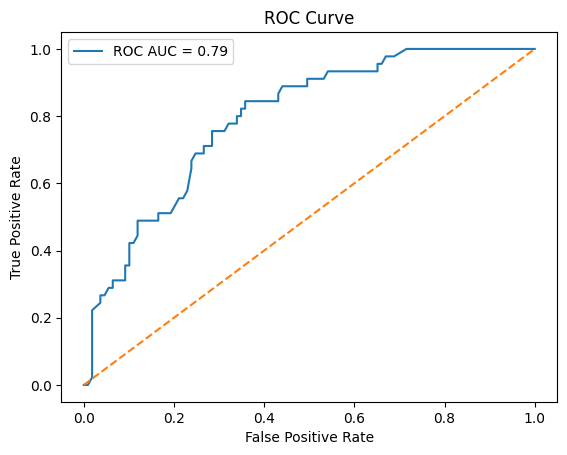

Gini Coefficient: -62.9333


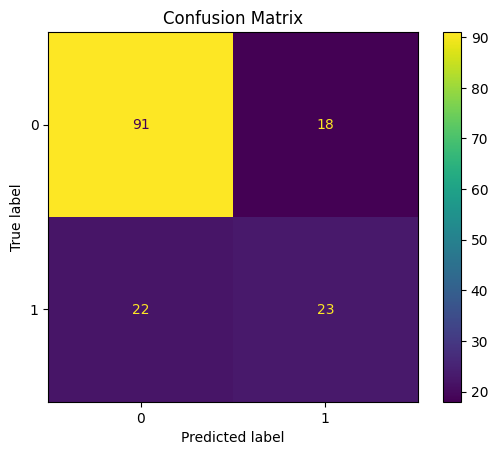

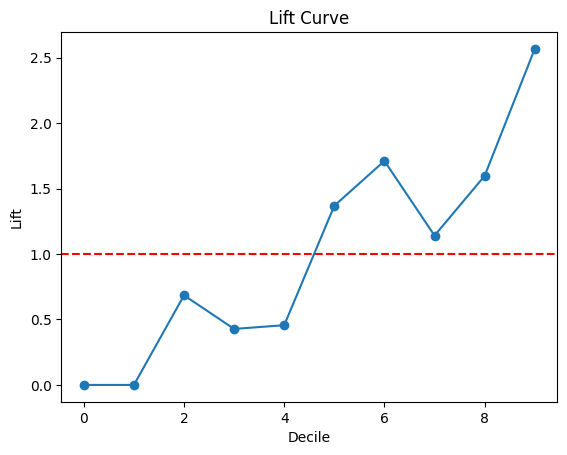

Précision: 0.56
Rappel: 0.51
F1-Score: 0.53
Log Loss: 0.50


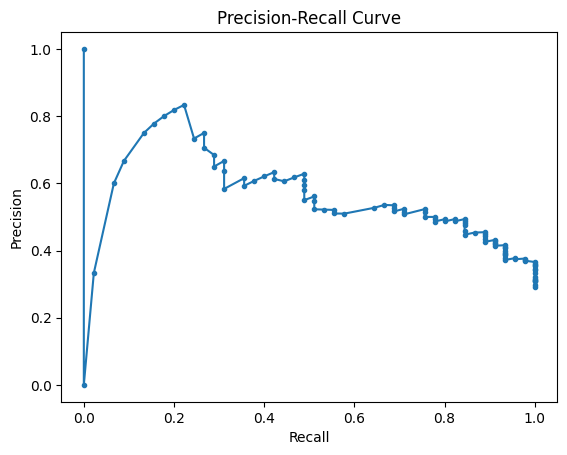

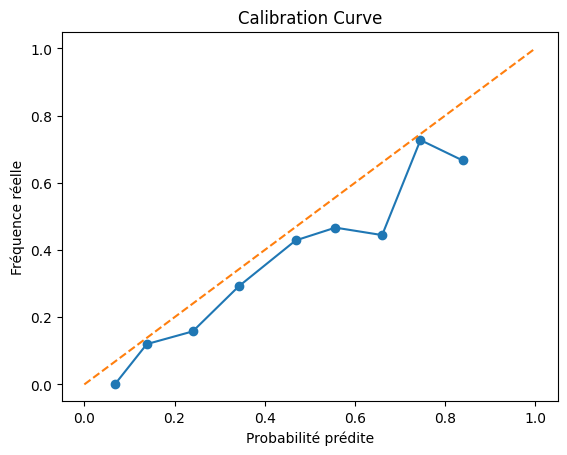

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score, log_loss, precision_recall_curve
)
from sklearn.calibration import calibration_curve

# Définition de la fonction plot_lift_curve
def plot_lift_curve(y_true, y_proba, n_bins=10):
    df = pd.DataFrame({"y_true": y_true, "y_proba": y_proba})
    df["decile"] = pd.qcut(df["y_proba"], n_bins, labels=False)
    lift = df.groupby("decile").apply(lambda x: (x["y_true"].sum() / x["y_true"].count()) / (y_true.sum() / len(y_true)))
    plt.plot(lift, marker="o")
    plt.axhline(y=1, color="r", linestyle="--")
    plt.xlabel("Decile")
    plt.ylabel("Lift")
    plt.title("Lift Curve")
    plt.show()

def calculate_ks_statistic(y_true, y_proba):
    """
    Mesure la séparation maximale entre les distributions 
    des scores prédits pour les deux classes (ex : "bons" vs "mauvais" clients).
    """
    df = pd.DataFrame({"y_true": y_true, "y_proba": y_proba})
    positive = df[df["y_true"] == 1]["y_proba"]
    negative = df[df["y_true"] == 0]["y_proba"]
    ks_statistic = max([abs((positive <= threshold).mean() - (negative <= threshold).mean())
                        for threshold in np.linspace(0, 1, 100)])
    return ks_statistic

# KS Statistic: the closer to 1, the better is the separation between the two classes
ks = calculate_ks_statistic(y_test, y_proba)
print(f"KS Statistic: {ks:.4f}")

# ROC AUC
roc_auc = roc_auc_score(y_test, y_proba)
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Gini Coefficient: the closer to 1, the better is the concentration of the scores
def calculate_gini(y_true, y_proba):
    """Alternative à l'AUC, souvent utilisée en finance pour mesurer la concentration des scores."""
    df = pd.DataFrame({"y_true": y_true, "y_proba": y_proba})
    df = df.sort_values("y_proba", ascending=False).reset_index(drop=True)
    df["cumulative_positive"] = df["y_true"].cumsum()
    df["cumulative_random"] = (df["y_true"].sum() / len(df)) * (df.index + 1)
    lorenz_area = (df["cumulative_positive"] - df["cumulative_random"]).sum() / df["cumulative_random"].iloc[-1]
    gini = 1 - (2 * lorenz_area)
    return gini

gini = calculate_gini(y_test, y_proba)
print(f"Gini Coefficient: {gini:.4f}")


# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix")
plt.show()

# Lift Curve
plot_lift_curve(y_test, y_proba)

# Métriques supplémentaires
print(f"Précision: {precision_score(y_test, y_pred):.2f}")
print(f"Rappel: {recall_score(y_test, y_pred):.2f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.2f}")
print(f"Log Loss: {log_loss(y_test, y_proba):.2f}")

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_proba)
plt.plot(recall, precision, marker=".")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

# Calibration Curve
prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)
plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Probabilité prédite")
plt.ylabel("Fréquence réelle")
plt.title("Calibration Curve")
plt.show()


## SHAP Values

Interpretation of the impact of each variable on the model predictions.  
Show the impact positive/negative of each feature on the prediction.

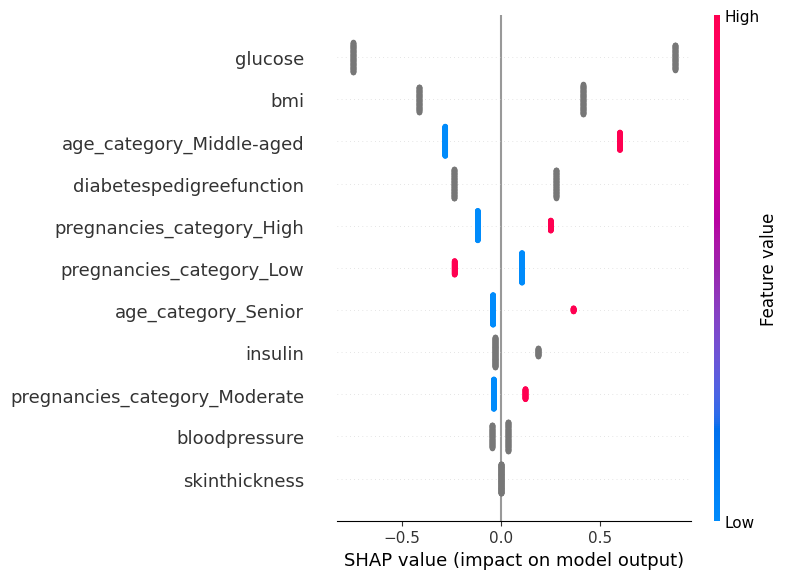

In [54]:
# !pip install shap
import shap

# SHAP Values
explainer = shap.LinearExplainer(model, X_train_final)
shap_values = explainer.shap_values(X_test_final)
shap.summary_plot(shap_values, X_test_final)

# END

In [82]:
# # Calculate the eigenvalues and the condition number
# eigenvalues, condition_number = calculate_eigenvalues_condition_number(X_train_dum_scale)
# print(f"\nCondition Number: {condition_number:.2f}")

# # Visualiser les eigenvalues
# plt.figure(figsize=(10, 6))
# plt.plot(eigenvalues, 'o-')
# plt.title('Scree Plot of Eigenvalues')
# plt.xlabel('Eigenvalue Index')
# plt.ylabel('Eigenvalue')
# plt.grid(True)
# plt.show()

**6. Pair Plot for Dummy Variables**  

Visualize the relationships between dummy variables using a pair plot.   

Interpretation:

Look for patterns that indicate strong associations between dummy variables.

In [81]:
# # Define degrees of freedom for each categorical variable
# degrees_of_freedom_dict = {
#     'age_category_middle_aged': 2,  # 3 levels - 1
#     'age_category_senior': 2,        # 3 levels - 1
#     'pregnancies_category_low': 3,        # 4 levels - 1
#     'pregnancies_category_moderate': 3,        # 4 levels - 1
#     'pregnancies_category_high': 3        # 4 levels - 1
# }

In [80]:
# from statsmodels.stats.outliers_influence import variance_inflation_factor
# import pandas as pd
# import numpy as np

# def calculate_multicollinearity(df, continuous_vars, dummy_vars, degrees_of_freedom_dict):
#     """
#     Calculate VIF for continuous variables and GVIF for dummy variables.

#     Parameters:
#     -----------
#     df : pd.DataFrame
#         DataFrame containing predictors.
#     continuous_vars : list
#         List of continuous variable names.
#     dummy_vars : list
#         List of dummy variable names.
#     degrees_of_freedom_dict : dict
#         Dictionary mapping dummy variables to their degrees of freedom.

#     Returns:
#     --------
#     pd.DataFrame
#         DataFrame with multicollinearity metrics for each variable.
#     """
#     df_with_const = df.assign(const=1)

#     results = []
#     for i, var in enumerate(df_with_const.columns):
#         vif = variance_inflation_factor(df_with_const.values, i)

#         if var in dummy_vars:
#             d = degrees_of_freedom_dict[var]
#             gif = vif ** (1 / (2 * d))
#             results.append({"Variable": var, "Metric": "GVIF", "Value": gif})
#         elif var in continuous_vars or var == 'const':
#             results.append({"Variable": var, "Metric": "VIF", "Value": vif})

#     return pd.DataFrame(results)


In [78]:
# multicollinearity_data = calculate_multicollinearity(X_train_dum_scale, continuous_vars, dummy_vars, degrees_of_freedom_dict)
# print(multicollinearity_data)

**2. Pearson correlation for numeric variables**

In [79]:
# X_train_float = X_train.select_dtypes(include='float')

# # Calculate Pearson correlation matrix
# corr_matrix = X_train_float.corr(method='pearson')

# # Visualize the correlation matrix
# plt.figure(figsize=(12, 8))
# sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
# plt.title('Correlation Matrix')
# plt.show()

**4. Point-Biserial correlation**

In [76]:
# from scipy.stats import pointbiserialr

# # Example: Calculate Point-Biserial correlation between a numeric and a dummy variable
# numeric_vars = ['glucose', 'bloodpressure', 'skinthickness', 'insulin', 'bmi', 'diabetespedigreefunction']
# dummy_vars = ['age_category_middle_aged', 'age_category_senior', 'pregnancies_category_low', 'pregnancies_category_moderate', 'pregnancies_category_high']

# point_biserial_results = pd.DataFrame(index=numeric_vars, columns=dummy_vars)

# for num_var in numeric_vars:
#     for dummy_var in dummy_vars:
#         corr, _ = pointbiserialr(X_train_dum[num_var], X_train_dum[dummy_var])
#         point_biserial_results.loc[num_var, dummy_var] = corr

# # Visualize the correlation matrix
# plt.figure(figsize=(12, 8))
# sns.heatmap(point_biserial_results.astype(float), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
# plt.title("Point-Biserial Correlation between Numeric and Dummy Variables")
# plt.show()

**5. Eigenvalues and Condition Number**  

In [83]:
# X_train_eigen = X_train_dum.copy()

# # Check for NaN values
# if X_train_eigen.isnull().sum().sum() > 0:
#     print("NaN values found. Dropping rows with NaN values.")
#     X_train_eigen = X_train_eigen.dropna()

# # Check for Inf values
# if np.isinf(X_train_eigen).sum().sum() > 0:
#     print("Inf values found. Replacing Inf with NaN and dropping rows with NaN values.")
#     X_train_eigen = X_train_eigen.replace([np.inf, -np.inf], np.nan)
#     X_train_eigen = X_train_eigen.dropna()

# # Check variance of each feature
# if (X_train_eigen.var() == 0).any():
#     print("Features with zero variance found. Dropping these features.")
#     X_train_eigen = X_train_eigen.loc[:, X_train_eigen.var() > 0]

# # Calculate eigenvalues and condition number
# corr_matrix = X_train_eigen.corr()
# eigenvalues = np.linalg.eigvals(corr_matrix)
# condition_number = np.max(eigenvalues) / np.min(eigenvalues)
# print(f"Condition Number: {condition_number:.2f}")

# plt.figure(figsize=(10, 6))
# plt.plot(eigenvalues, 'o-')
# plt.title('Scree Plot of Eigenvalues')
# plt.xlabel('Eigenvalue Index')
# plt.ylabel('Eigenvalue')
# plt.grid(True)
# plt.show()

**6. Pair Plot for Dummy Variables**  

Visualize the relationships between dummy variables using a pair plot.   

Interpretation:

Look for patterns that indicate strong associations between dummy variables.

In [75]:
# # Pair plot for dummy variables
# sns.pairplot(X_train_dum[dummy_vars])
# plt.title("Pair Plot for Dummy Variables")
# plt.show()

#### **Fit the logistic regression model**

##### Logistic Regression with scipy

#### **Linearity of Log-Odds**

Predicted Probabilities and Log-Odds:

* The linearity of log-odds assumption in logistic regression refers to the relationship between continuous predictors and the log-odds of the outcome.
* To assess this, you need the predicted probabilities from a fitted logistic regression model. These probabilities are then transformed into log-odds.  

Visual Inspection:

* You plot the continuous predictors against the predicted log-odds to visually inspect if the relationship is linear.
* If the relationship is not linear, you may need to transform the predictor (e.g., using polynomials, splines, or categorization).

##### Calculate Predicted Probabilities and Log-Odds

In [70]:
# # Compute the predicted probabilities
# X_train['predicted_prob'] = result.predict(X_train_with_const)

# # Calculate predicted log-odds
# X_train['predicted_log_odds'] = np.log(X_train['predicted_prob'] / (1 - X_train['predicted_prob']))

In [69]:
# X_train['predicted_log_odds'] = np.log(X_train['predicted_prob'] / (1 - X_train['predicted_prob']))

# # Plot log-odds vs each continuous predictor
# for predictor in ['pregnancies','glucose', 'bloodpressure', 'skinthickness', 'insulin', 'bmi', 'diabetespedigreefunction']:
#     plt.figure(figsize=(8, 5))
#     plt.scatter(X_train[predictor], X_train['predicted_log_odds'], alpha=0.5)
#     plt.title(f'Log-Odds vs {predictor}')
#     plt.xlabel(predictor)
#     plt.ylabel('Log-Odds of Y=1')
#     plt.axhline(0, color='red', linestyle='--')
#     plt.show()

##### Plot Log-Odds vs. Continuous Predictors

In [68]:
# continuous_predictors = ['glucose', 'bloodpressure', 'skinthickness', 'insulin', 'bmi', 'diabetespedigreefunction']

# for predictor in continuous_predictors:
#     plt.figure(figsize=(8, 5))
#     plt.scatter(X_train[predictor], X_train['predicted_log_odds'], alpha=0.5)
#     plt.title(f'Log-Odds vs {predictor}')
#     plt.xlabel(predictor)
#     plt.ylabel('Log-Odds of Y=1')
#     plt.axhline(0, color='red', linestyle='--')
#     plt.grid(True)
#     plt.show()

In [63]:
# # Check the hypothesis of linearity of log-odds for continuous predictors using plots.
# import matplotlib.pyplot as plt
# for predictor in ['pregnancies','glucose','bloodpressure','skinthickness','insulin','bmi','diabetespedigreefunction']:
#     plt.figure(figsize=(8, 5))
#     plt.scatter(X_train_dum[predictor], np.log(X_train_dum['predicted_prob'] / (1 - X_train_dum['predicted_prob'])), alpha=0.5)
#     plt.title(f'Log-Odds vs {predictor}')
#     plt.xlabel(predictor)
#     plt.ylabel('Log-Odds of Y=1')
#     plt.axhline(0, color='red', linestyle='--')
#     plt.show()

**Example with categorical features**

* Dataset preparation

* Fit the logit model

* Check the hypothesis of linearity of log-odds for continuous predictors using plots.

In [64]:
# # Calculate predicted probabilities
# data_dummies['predicted_prob'] = result.predict(X)

# # Calculate predicted log-odds
# data_dummies['predicted_log_odds'] = np.log(data_dummies['predicted_prob'] / (1 - data_dummies['predicted_prob']))

# # Add the original category back for plotting
# data_dummies['category'] = data['category']


In [65]:
# # Calculate predicted probabilities
# diabetes_dummies['predicted_prob'] = result.predict(X)

# # Calculate predicted log-odds
# diabetes_dummies['predicted_log_odds'] = np.log(diabetes_dummies['predicted_prob'] / (1 - diabetes_dummies['predicted_prob']))

In [66]:
# # Plot the log-odds for each age category
# plt.figure(figsize=(8, 6))
# sns.boxplot(x='age_category', y='predicted_log_odds', data=diabetes_dummies)
# plt.axhline(y=0, color='red', linestyle='--')
# plt.title('Log-Odds by Age Category')
# plt.xlabel('Age Category')
# plt.ylabel('Predicted Log-Odds')
# plt.show()

In [67]:
# # Plot the log-odds for each glucose category
# plt.figure(figsize=(8, 6))
# sns.boxplot(x='glucose_category', y='predicted_log_odds', data=diabetes_dummies)
# plt.axhline(y=0, color='red', linestyle='--')
# plt.title('Log-Odds by Glucose Category')
# plt.xlabel('Glucose Category')
# plt.ylabel('Predicted Log-Odds')
# plt.show()

6. Interpretation of the Plots

* Consistency of Log-Odds: The boxplot will show the distribution of predicted log-odds for each category. If the medians of the log-odds for each category are distinct, it suggests that the categorical predictor is having an effect on the log-odds of the outcome.

* Effect of Categories: The difference in log-odds between categories should reflect the coefficients in the logistic regression output.